# COGS 108 - EDA Checkpoint

## Authors

- Mia Mayer: Conceptualization, Project administration, Writing – review & editing
- Julia Visaya: Data curation, Software, Writing – review & editing
- Hemi Kim: Analysis, Data curation, Software, Visualization, Writing – original draft
- Katelyn Ma: Background research, Writing – review & editing
- Catherine Do: Background research, Writing – original draft- 

# Research Question

Is there a statistically significant association between institutional funding levels at U.S. public colleges and the median annual earnings of graduates approximately ten years after enrollment?

Funding will be measured using institution-level financial variables such as total revenue, instructional expenditures, and state and federal appropriations obtained from IPEDS/NCES. Graduate outcomes will be measured using the College Scorecard median earnings metric at approximately ten years after completion.

To account for potential confounding factors, we will include controls for institutional scale (enrollment and completions), geographic variation (state/region), and regional cost-of-living proxies (ACS median household income). This is a statistical inference project using correlation and regression analyses.

## Background and Prior Work

Public higher education funding plays a central role in discussions about economic mobility and workforce outcomes in the United States. Public colleges and universities educate a substantial portion of the nation’s working population and receive funding from a combination of state appropriations, federal support, and tuition revenue.<a name="cite_ref-1"></a>[<sup>1</sup>](#cite_note-1) However, funding levels vary significantly across states and institutions due to differences in state budgets, enrollment patterns, and regional economic priorities.<a name="cite_ref-2"></a>[<sup>2</sup>](#cite_note-2) These disparities raise an important question: does greater institutional investment translate into stronger long-term economic outcomes for graduates?

To investigate this relationship, we draw on publicly available administrative datasets from the National Center for Education Statistics (NCES), IPEDS, and the U.S. Department of Education’s College Scorecard. These sources provide institution-level data on funding, enrollment, completions, tuition, and graduate earnings.<a name="cite_ref-3"></a>[<sup>3</sup>](#cite_note-3) In particular, College Scorecard includes median earnings metrics approximately ten years after enrollment, allowing us to examine long-term labor market outcomes.<a name="cite_ref-6"></a>[<sup>6</sup>](#cite_note-6)

A key challenge when comparing earnings across institutions is geographic variation in labor markets and cost of living. Similar nominal salaries may imply different standards of living depending on regional economic conditions. To address this, we incorporate regional socioeconomic context using American Community Survey (ACS) data, including median household income as a cost-of-living proxy.<a name="cite_ref-4"></a>[<sup>4</sup>](#cite_note-4) Including these controls helps reduce omitted variable bias when estimating the association between funding and earnings.

This project also builds on prior education-focused data science analyses. A previous COGS 108 project, *Are Universities Worth the Opportunity Cost?*, examined institutional-level education and earnings outcomes using similar federal datasets.<a name="cite_ref-5"></a>[<sup>5</sup>](#cite_note-5) That work provides a methodological foundation for linking institutional characteristics to measurable labor market outcomes, which we extend by focusing specifically on institutional funding as a predictor of long-term graduate earnings.

---

### References

1. <a name="cite_note-1"></a>[^](#cite_ref-1) National Center for Education Statistics (NCES). *Digest of Education Statistics*. https://nces.ed.gov/programs/digest/
2. <a name="cite_note-2"></a>[^](#cite_ref-2) NCES Condition of Education — Postsecondary Institution Revenue. https://nces.ed.gov/programs/coe/indicator/cud/postsecondary-institution-revenue
3. <a name="cite_note-3"></a>[^](#cite_ref-3) Integrated Postsecondary Education Data System (IPEDS). https://nces.ed.gov/ipeds/
4. <a name="cite_note-4"></a>[^](#cite_ref-4) U.S. Census Bureau — American Community Survey (ACS) Table B19013. https://data.census.gov/
5. <a name="cite_note-5"></a>[^](#cite_ref-5) COGS 108 Final Project (Sp17): *Are Universities Worth the Opportunity Cost?* https://github.com/COGS108/FinalProjects-Sp17/blob/master/081-FinalProject.ipynb
6. <a name="cite_note-6"></a>[^](#cite_ref-6) College Scorecard — Data Documentation and Bulk Downloads. https://collegescorecard.ed.gov/data/

# Hypothesis


We hypothesize that higher levels of institutional funding at public colleges are positively associated with higher median earnings approximately ten years after enrollment.

Specifically, we predict that instructional expenditures per student and total revenue per student will show a statistically significant positive correlation with long-term graduate earnings. We expect this relationship to remain significant even after controlling for institutional scale, geographic variation, and regional socioeconomic factors.

Our reasoning is that greater institutional funding may support smaller student-to-faculty ratios, improved academic resources, expanded career services, and stronger industry connections, all of which may enhance students’ human capital and labor market outcomes.

## Data

### Data Overview

Our project uses publicly available administrative datasets from the National Center for Education Statistics (NCES), the Integrated Postsecondary Education Data System (IPEDS), and the U.S. Department of Education College Scorecard.

This project integrates three federal administrative data sources:

1. IPEDS (NCES) for institutional finance and enrollment data.
2. U.S. Department of Education College Scorecard for graduate earnings and geographic identifiers.
3. U.S. Census Bureau American Community Survey (ACS) for state-level median household income as a cost-of-living proxy.

These datasets were merged using institutional identifiers (`UNITID`) and state postal abbreviations (`STABBR`).

### Dataset #1: IPEDS Institutional Finance Data (2012)

This dataset contains institution-level financial and enrollment data for U.S. public colleges and universities obtained from the Integrated Postsecondary Education Data System (IPEDS), maintained by the National Center for Education Statistics (NCES).

The unit of observation is the institution, identified by `UNITID`.

Key variables used in this project include:

- `instruction_exp_2012`: Total instructional expenditures in U.S. dollars. This includes faculty salaries, instructional support, and other direct instructional costs.
- `enrollment_2012`: Total student enrollment.
- `funding_per_student_2012`: Instructional expenditures divided by enrollment, representing per-student instructional spending.

Instructional expenditures were converted to per-student funding to account for institutional size differences, as larger institutions naturally have higher total expenditures.

Potential concerns include variation in institutional accounting practices and the fact that instructional expenditures do not capture all revenue sources (e.g., endowments or private donations).

In [34]:
import pandas as pd
import numpy as np

# Load merged IPEDS + Scorecard dataset created during Data Checkpoint
df = pd.read_csv("data/02-processed/merged_ipeds2012_scorecard2012_13.csv")

# Isolate funding-related variables for inspection
ipeds_subset = df[["UNITID", "instruction_exp_2012", "enrollment_2012", "funding_per_student_2012"]]

# Display first few rows
ipeds_subset.head()

,UNITID,instruction_exp_2012,enrollment_2012,funding_per_student_2012
0,138558,10812772.0,3233.0,3344.501083
1,126182,20371768.0,3290.0,6192.026748
2,100654,37967292.0,4853.0,7823.468370
3,100724,42848156.0,5816.0,7367.289546
4,138716,28153311.0,4275.0,6585.569825


In [35]:
ipeds_subset.shape

(636, 4)

In [36]:
ipeds_subset.isna().sum()

UNITID                      0
instruction_exp_2012        0
enrollment_2012             0
funding_per_student_2012    0
dtype: int64

In [37]:
ipeds_subset.describe()

,UNITID,instruction_exp_2012,enrollment_2012,funding_per_student_2012
count,636.000000,6.360000e+02,636.000000,636.000000
mean,183637.044025,1.070996e+08,12301.767296,9329.452891
std,49891.754087,1.523262e+08,11588.545259,14888.693575
min,100654.000000,0.000000e+00,205.000000,0.000000
25%,148434.500000,2.243064e+07,3767.500000,5009.187282
50%,184955.500000,5.411952e+07,8293.000000,6399.944574
75%,216219.500000,1.217680e+08,16994.250000,8645.596036
max,451671.000000,1.450832e+09,73378.000000,253742.803630


### Dataset #2: College Scorecard Earnings Data

This dataset contains institution-level student outcome metrics from the U.S. Department of Education College Scorecard. The unit of observation is the institution, identified by `UNITID`.

Key variable used:
- `MD_EARN_WNE_P10`: Median annual earnings (USD) approximately 10 years after enrollment.

This variable represents the median earnings of former students who received federal financial aid, measured roughly ten years after entering the institution. Earnings values were converted to numeric format, and institutions missing earnings data were excluded during the merging process, as earnings are required to evaluate our research question.

After merging with IPEDS financial data, the dataset contains 636 institutions.

The College Scorecard dataset also provides institutional geographic identifiers, including state postal abbreviation (`STABBR`) and Census region code (`REGION`), which are used for geographic controls in subsequent analyses.

In [38]:
scorecard_raw = pd.read_csv("data/00-raw/MERGED2012_13_PP.csv", low_memory = False)
scorecard_raw.columns[:50]

Index(['UNITID', 'OPEID', 'OPEID6', 'INSTNM', 'CITY', 'STABBR', 'ZIP',
       'ACCREDAGENCY', 'INSTURL', 'NPCURL', 'SCH_DEG', 'HCM2', 'MAIN',
       'NUMBRANCH', 'PREDDEG', 'HIGHDEG', 'CONTROL', 'ST_FIPS', 'REGION',
       'LOCALE', 'LOCALE2', 'LATITUDE', 'LONGITUDE', 'CCBASIC', 'CCUGPROF',
       'CCSIZSET', 'HBCU', 'PBI', 'ANNHI', 'TRIBAL', 'AANAPII', 'HSI', 'NANTI',
       'MENONLY', 'WOMENONLY', 'RELAFFIL', 'ADM_RATE', 'ADM_RATE_ALL',
       'SATVR25', 'SATVR75', 'SATMT25', 'SATMT75', 'SATWR25', 'SATWR75',
       'SATVRMID', 'SATMTMID', 'SATWRMID', 'ACTCM25', 'ACTCM75', 'ACTEN25'],
      dtype='str')

In [39]:
state_df  = scorecard_raw[["UNITID", "STABBR"]].copy()
region_df = scorecard_raw[["UNITID", "REGION"]].copy()

earnings_subset = df[["UNITID", "MD_EARN_WNE_P10"]]
earnings_subset.head()

,UNITID,MD_EARN_WNE_P10
0,138558,32000.0
1,126182,32800.0
2,100654,30300.0
3,100724,26600.0
4,138716,31500.0


In [40]:
earnings_subset.shape

(636, 2)

In [41]:
earnings_subset.isna().sum()

UNITID             0
MD_EARN_WNE_P10    0
dtype: int64

In [42]:
earnings_subset.describe()

,UNITID,MD_EARN_WNE_P10
count,636.000000,636.000000
mean,183637.044025,41747.327044
std,49891.754087,17210.897731
min,100654.000000,17200.000000
25%,148434.500000,34100.000000
50%,184955.500000,39000.000000
75%,216219.500000,44425.000000
max,451671.000000,219900.000000


### Dataset #3: American Community Survey (ACS) Median Household Income (2012)

This dataset contains state-level median household income estimates from the U.S. Census Bureau’s American Community Survey (ACS) 5-Year Estimates (2012).

The unit of observation is the state.

Key variable used:
- `median_household_income`: Median household income (USD) for each U.S. state and the District of Columbia.

The dataset was downloaded directly from data.census.gov (Table B19013: Median Household Income in the Past 12 Months) and converted from wide format to long format. State names were mapped to standard postal abbreviations (STABBR) to align with the College Scorecard dataset.

Territories not included in the ACS state table (AS, MP, GU, VI) were excluded from analyses requiring this cost-of-living proxy.

In [43]:
import pandas as pd

acs_raw = pd.read_csv("data/00-raw/acs_median_income_2012.csv")

estimate_cols = [col for col in acs_raw.columns if "!!Estimate" in col]

acs_row = acs_raw.loc[0, estimate_cols]

acs_long = acs_row.reset_index()
acs_long.columns = ["state_full", "median_household_income"]

acs_long["state_full"] = acs_long["state_full"].str.replace("!!Estimate", "", regex = False)
acs_long["median_household_income"] = (
    acs_long["median_household_income"]
    .str.replace(",", "", regex=False)
    .astype(float)
)

state_map = {
    "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR",
    "California": "CA", "Colorado": "CO", "Connecticut": "CT", "Delaware": "DE",
    "Florida": "FL", "Georgia": "GA", "Hawaii": "HI", "Idaho": "ID",
    "Illinois": "IL", "Indiana": "IN", "Iowa": "IA", "Kansas": "KS",
    "Kentucky": "KY", "Louisiana": "LA", "Maine": "ME", "Maryland": "MD",
    "Massachusetts": "MA", "Michigan": "MI", "Minnesota": "MN", "Mississippi": "MS",
    "Missouri": "MO", "Montana": "MT", "Nebraska": "NE", "Nevada": "NV",
    "New Hampshire": "NH", "New Jersey": "NJ", "New Mexico": "NM",
    "New York": "NY", "North Carolina": "NC", "North Dakota": "ND",
    "Ohio": "OH", "Oklahoma": "OK", "Oregon": "OR", "Pennsylvania": "PA",
    "Rhode Island": "RI", "South Carolina": "SC", "South Dakota": "SD",
    "Tennessee": "TN", "Texas": "TX", "Utah": "UT", "Vermont": "VT",
    "Virginia": "VA", "Washington": "WA", "West Virginia": "WV",
    "Wisconsin": "WI", "Wyoming": "WY", "Puerto Rico": "PR", 
    "District of Columbia": "DC"
}

acs_long["STABBR"] = acs_long["state_full"].map(state_map)

acs_clean = acs_long[["STABBR", "median_household_income"]].dropna()

acs_clean.head(), acs_clean.shape

(  STABBR  median_household_income
 0     AL                  41574.0
 1     AK                  67712.0
 2     AZ                  47826.0
 3     AR                  40112.0
 4     CA                  58328.0,
 (52, 2))

### Data Merging and Final Analytic Dataset

IPEDS institutional finance and enrollment data were merged with College Scorecard earnings data using the shared institutional identifier `UNITID`.

Institutions missing key variables (funding per student or median earnings) were excluded. A reporting artifact in which one institution recorded zero instructional expenditures was also removed prior to log-transformed analysis.

State-level median household income from the 2012 ACS 5-Year Estimates was merged using state postal abbreviations (`STABBR`). Institutions located in U.S. territories not included in the ACS state table (AS, MP, GU, VI) were excluded from analyses requiring the cost-of-living proxy.

The final analytic dataset used for multivariate modeling contains 631 institutions and includes the following primary variables:

- `funding_per_student_2012`
- `MD_EARN_WNE_P10`
- `enrollment_2012`
- `median_household_income`
- `REGION`
- log-transformed funding and earnings variables

In [44]:
import numpy as np

# Start from the processed dataset created during Data Checkpoint
df = pd.read_csv("data/02-processed/merged_ipeds2012_scorecard2012_13.csv")

# Defensive: avoid duplicate columns if re-running
df = df.drop(columns=["STABBR", "REGION", "median_household_income"], errors="ignore")

# Merge Scorecard geography FIRST
df = df.merge(state_df,  on="UNITID", how="left")
df = df.merge(region_df, on="UNITID", how="left")

assert df["STABBR"].isna().sum() == 0
assert df["REGION"].isna().sum() == 0

# Merge ACS SECOND
df = df.merge(acs_clean, on="STABBR", how="left")

# Final analytic dataset used for models requiring ACS (drops territories)
df_acs = df.dropna(subset=["median_household_income"]).copy()

# Remove zero-funding reporting artifact (needed for log transforms)
df_acs = df_acs[df_acs["funding_per_student_2012"] > 0].copy()

# Compute logs once on final dataset
df_acs["log_funding"]  = np.log(df_acs["funding_per_student_2012"])
df_acs["log_earnings"] = np.log(df_acs["MD_EARN_WNE_P10"])

df_acs.shape, df_acs.head()

((631, 10),
    UNITID  instruction_exp_2012  enrollment_2012  funding_per_student_2012  \
 0  138558            10812772.0           3233.0               3344.501083   
 1  126182            20371768.0           3290.0               6192.026748   
 2  100654            37967292.0           4853.0               7823.468370   
 3  100724            42848156.0           5816.0               7367.289546   
 4  138716            28153311.0           4275.0               6585.569825   
 
    MD_EARN_WNE_P10 STABBR  REGION  median_household_income  log_funding  \
 0          32000.0     GA       5                  47209.0     8.115073   
 1          32800.0     CO       7                  56765.0     8.731018   
 2          30300.0     AL       5                  41574.0     8.964883   
 3          26600.0     AL       5                  41574.0     8.904805   
 4          31500.0     GA       5                  47209.0     8.792636   
 
    log_earnings  
 0     10.373491  
 1     10.398184

## Results

### Exploratory Data Analysis

All exploratory analyses below use the final analytic dataset (df_acs, n=631) constructed in the Data section, which excludes institutions missing ACS income data and removes a single zero-funding reporting artifact prior to log transformation.

#### Distribution of Funding

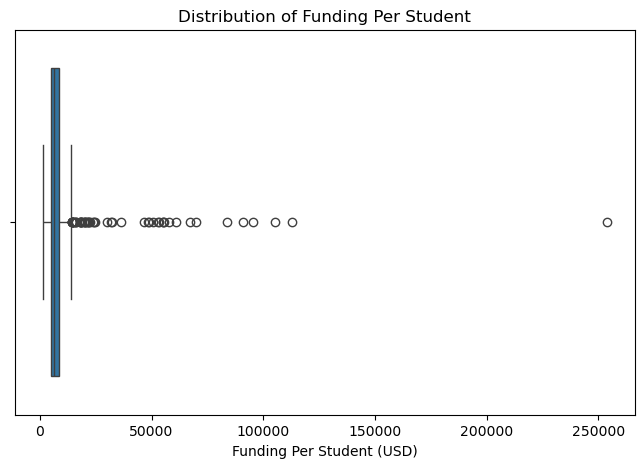

In [45]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df_acs["funding_per_student_2012"])
plt.title("Distribution of Funding Per Student")
plt.xlabel("Funding Per Student (USD)")
plt.show()

Funding per student is highly right-skewed. While most institutions spend between roughly $4,000 and $9,000 per student, a small number of institutions report substantially higher instructional expenditures. This skew motivates the use of log transformations in subsequent analyses.

In [46]:
df_acs.groupby("STABBR")["MD_EARN_WNE_P10"].mean().sort_values(ascending=False).head(10)

STABBR
MA    57050.000000
NJ    54790.909091
CA    53356.250000
WV    49809.090909
MD    49669.230769
NY    48690.697674
TX    48654.545455
VA    46886.666667
OR    46387.500000
IA    46300.000000
Name: MD_EARN_WNE_P10, dtype: float64

In [47]:
df_acs.groupby("STABBR")["MD_EARN_WNE_P10"].mean().sort_values().head(10)

STABBR
PR    19800.000000
NM    31788.888889
DE    33600.000000
FL    34041.176471
MS    34100.000000
DC    34800.000000
KY    34862.500000
ND    35233.333333
MT    35250.000000
NV    35680.000000
Name: MD_EARN_WNE_P10, dtype: float64

Average graduate earnings vary substantially across states. For example, states such as Massachusetts and New Jersey exhibit average earnings above $55,000, while several southern states and territories report substantially lower values. These patterns suggest that geographic labor market conditions may influence graduate outcomes.

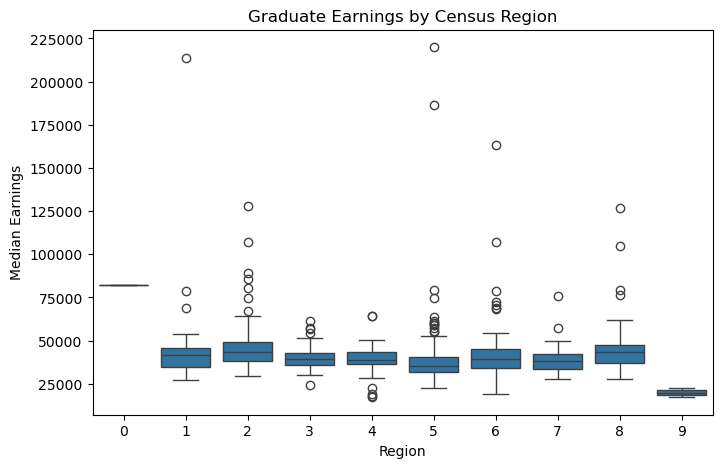

In [48]:
plt.figure(figsize=(8,5))
sns.boxplot(x="REGION", y="MD_EARN_WNE_P10", data=df_acs)
plt.title("Graduate Earnings by Census Region")
plt.xlabel("Region")
plt.ylabel("Median Earnings")
plt.show()

Earnings also vary across Census regions. Some regions exhibit systematically higher graduate earnings than others, suggesting that regional labor markets and economic conditions may affect post-college outcomes independently of institutional characteristics.

#### Funding vs. Earnings Relationship

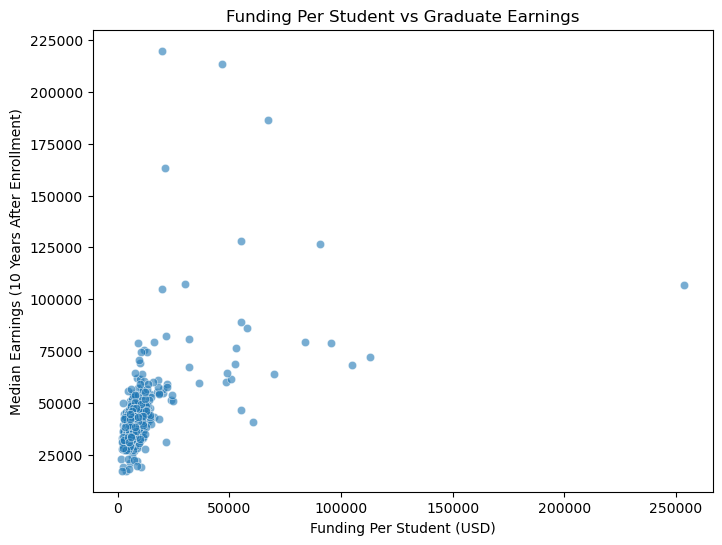

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.scatterplot(
    x="funding_per_student_2012", 
    y="MD_EARN_WNE_P10", 
    data=df_acs, alpha=0.6)

plt.xlabel("Funding Per Student (USD)")
plt.ylabel("Median Earnings (10 Years After Enrollment)")
plt.title("Funding Per Student vs Graduate Earnings")
plt.show()

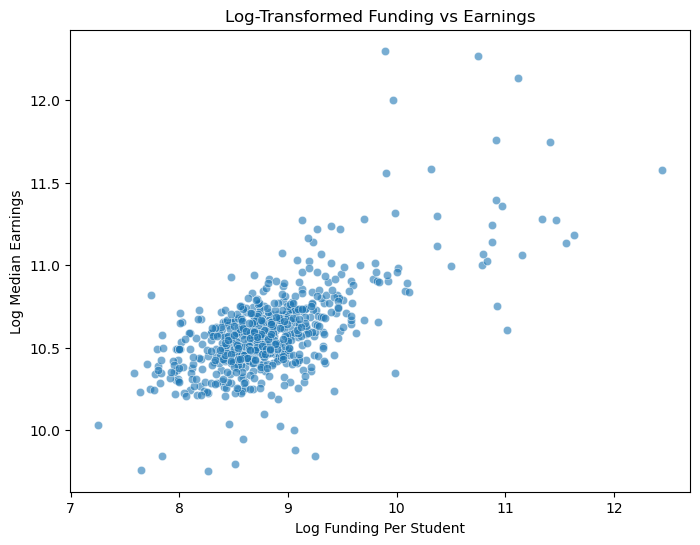

In [50]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="log_funding",
    y="log_earnings",
    data=df_acs,
    alpha=0.6
)

plt.xlabel("Log Funding Per Student")
plt.ylabel("Log Median Earnings")
plt.title("Log-Transformed Funding vs Earnings")
plt.show()

The log-transformed scatterplot reveals a clearer positive linear relationship between funding per student and median graduate earnings.

Log transformation reduces the influence of extreme outliers and compresses the scale of highly skewed funding values. The relationship appears more approximately linear in log space, suggesting that a log-log regression model may better satisfy linearity and normality assumptions.

In [51]:
raw_corr = df["funding_per_student_2012"].corr(df["MD_EARN_WNE_P10"])
log_corr = df["log_funding"].corr(df["log_earnings"])
raw_corr, log_corr

KeyError: 'log_funding'

The Pearson correlation between funding per student and median graduate earnings is approximately 0.52 in raw space and increases to about 0.67 in log-transformed space.

This indicates a moderate to strong positive association between institutional funding and long-term earnings outcomes. The stronger correlation in log space suggests that skewness in the original variables partially obscured the linear relationship.

In [ ]:
plt.figure(figsize=(8,6))
sns.regplot(
    x="log_funding",
    y="log_earnings",
    data=df_acs,
    scatter_kws={"alpha":0.5}
)

plt.xlabel("Log Funding Per Student")
plt.ylabel("Log Median Earnings")
plt.title("Log-Log Relationship with Regression Line")
plt.show()

The log-log regression line confirms a positive association between institutional funding per student and median graduate earnings.

The approximately linear pattern in log-transformed variables supports the use of a log-log regression model in subsequent statistical analysis.

In [32]:
enroll_earn_corr = df_acs["enrollment_2012"].corr(df_acs["MD_EARN_WNE_P10"])
enroll_fund_corr = df_acs["enrollment_2012"].corr(df_acs["funding_per_student_2012"])
enroll_earn_corr, enroll_fund_corr

(np.float64(0.05964330934535942), np.float64(-0.04520175822293274))

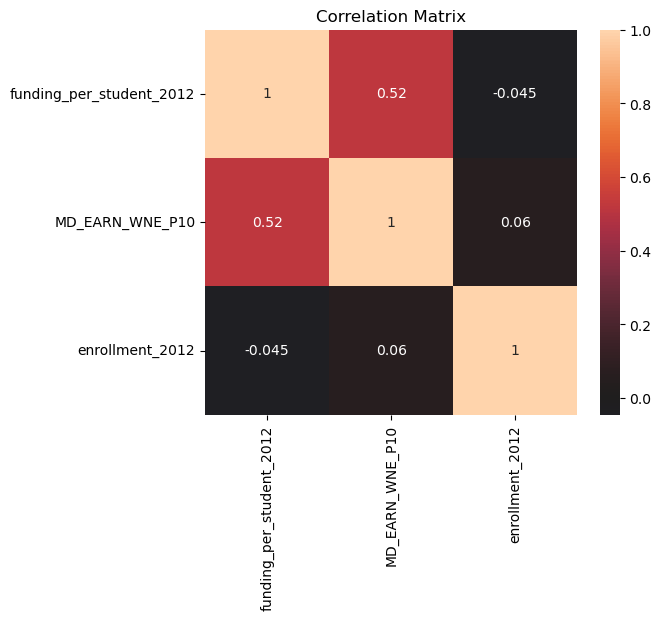

In [33]:
plt.figure(figsize=(6,5))
sns.heatmap(df_acs[["funding_per_student_2012","MD_EARN_WNE_P10","enrollment_2012"]].corr(),
            annot=True, center=0)
plt.title("Correlation Matrix")
plt.show()

We examined whether institutional scale (enrollment) is strongly associated with either funding per student or median graduate earnings.

The correlation between enrollment and earnings is 0.06, and the correlation between enrollment and funding per student is −0.04. Both values are close to zero, indicating little linear association.

This suggests that institutional size is unlikely to be a major confounding factor in the observed funding–earnings relationship. However, enrollment will still be included as a control variable in subsequent regression analysis.

## Ethics

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Team Expectations 

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Project Timeline Proposal

In [ ]:
Instructions: Replace this with your timeline.  **PLEASE UPDATE your Timeline!** No battle plan survives contact with the enemy, so make sure we understand how your plans have changed.  Also if you have lost points on the previous checkpoint fix them